# EDA

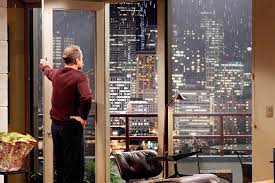

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

## Who am I, who is my client

I'm analyzing the King County housing dataset on behalf of **Thomas Hansen**, a home **buyer**.

**Client characteristics:**
- 5 kids, limited budget ("no money")
- Wants a nice, socially dense (family-friendly) neighborhood
- Open questions: best **timing** to buy, and best **location**

## The data

- **Source**: King County housing sales (Seattle, USA area), loaded from the `eda` schema of our PostgreSQL database via `03_fetching_the_data_eda.ipynb`, joining house details with their sale price/date.
- **Size**: 21,597 rows (sales), 21 columns.
- **Time span / location**: covered below once the data is loaded.

In [2]:
# Load the data exported by 03_fetching_the_data_eda.ipynb
df = pd.read_csv("data/eda.csv", parse_dates=["date"])

print(df.shape)
df.head()

(21597, 21)


,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3.000,1.000,1180.000,5650.000,1.000,NaN,0.000,3,7,...,0.000,1955,0.000,98178,47.511,-122.257,1340.000,5650.000,2014-10-13,221900.000
1,6414100192,3.000,2.250,2570.000,7242.000,2.000,0.000,0.000,3,7,...,400.000,1951,19910.000,98125,47.721,-122.319,1690.000,7639.000,2014-12-09,538000.000
2,5631500400,2.000,1.000,770.000,10000.000,1.000,0.000,0.000,3,6,...,0.000,1933,NaN,98028,47.738,-122.233,2720.000,8062.000,2015-02-25,180000.000
3,2487200875,4.000,3.000,1960.000,5000.000,1.000,0.000,0.000,5,7,...,910.000,1965,0.000,98136,47.521,-122.393,1360.000,5000.000,2014-12-09,604000.000
4,1954400510,3.000,2.000,1680.000,8080.000,1.000,0.000,0.000,3,8,...,0.000,1987,0.000,98074,47.617,-122.045,1800.000,7503.000,2015-02-18,510000.000


## Data overview

Before touching any client-specific questions, let's understand the shape, types, and quality of the raw data: descriptive statistics, missing values, and the time/geographic span it covers.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21597 non-null  int64         
 1   bedrooms       21597 non-null  float64       
 2   bathrooms      21597 non-null  float64       
 3   sqft_living    21597 non-null  float64       
 4   sqft_lot       21597 non-null  float64       
 5   floors         21597 non-null  float64       
 6   waterfront     19206 non-null  float64       
 7   view           21534 non-null  float64       
 8   condition      21597 non-null  int64         
 9   grade          21597 non-null  int64         
 10  sqft_above     21597 non-null  float64       
 11  sqft_basement  21145 non-null  float64       
 12  yr_built       21597 non-null  int64         
 13  yr_renovated   17749 non-null  float64       
 14  zipcode        21597 non-null  int64         
 15  lat            21597 non-null 

In [4]:
df.describe()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
count,21597.000,21597.000,21597.000,21597.000,21597.000,21597.000,19206.000,21534.000,21597.000,21597.000,...,21145.000,21597.000,17749.000,21597.000,21597.000,21597.000,21597.000,21597.000,21597,21597.000
mean,4580474287.771,3.373,2.116,2080.322,15099.409,1.494,0.008,0.234,3.410,7.658,...,291.857,1971.000,836.651,98077.952,47.560,-122.214,1986.620,12758.284,2014-10-29 04:20:38.171968,540296.574
min,1000102.000,1.000,0.500,370.000,520.000,1.000,0.000,0.000,1.000,3.000,...,0.000,1900.000,0.000,98001.000,47.156,-122.519,399.000,651.000,2014-05-02 00:00:00,78000.000
25%,2123049175.000,3.000,1.750,1430.000,5040.000,1.000,0.000,0.000,3.000,7.000,...,0.000,1951.000,0.000,98033.000,47.471,-122.328,1490.000,5100.000,2014-07-22 00:00:00,322000.000
50%,3904930410.000,3.000,2.250,1910.000,7618.000,1.500,0.000,0.000,3.000,7.000,...,0.000,1975.000,0.000,98065.000,47.572,-122.231,1840.000,7620.000,2014-10-16 00:00:00,450000.000
75%,7308900490.000,4.000,2.500,2550.000,10685.000,2.000,0.000,0.000,4.000,8.000,...,560.000,1997.000,0.000,98118.000,47.678,-122.125,2360.000,10083.000,2015-02-17 00:00:00,645000.000
max,9900000190.000,33.000,8.000,13540.000,1651359.000,3.500,1.000,4.000,5.000,13.000,...,4820.000,2015.000,20150.000,98199.000,47.778,-121.315,6210.000,871200.000,2015-05-27 00:00:00,7700000.000
std,2876735715.748,0.926,0.769,918.106,41412.637,0.540,0.087,0.766,0.651,1.173,...,442.491,29.375,4000.111,53.513,0.139,0.141,685.230,27274.442,NaN,367368.140


In [5]:
# Missing values per column
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

# Time span and geographic span of the dataset
print(f"\nDate range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Number of distinct zipcodes: {df['zipcode'].nunique()}")
print(f"Latitude range: {df['lat'].min()} to {df['lat'].max()}")
print(f"Longitude range: {df['long'].min()} to {df['long'].max()}")

Missing values per column:
waterfront       2391
view               63
sqft_basement     452
yr_renovated     3848
dtype: int64

Date range: 2014-05-02 to 2015-05-27
Number of distinct zipcodes: 70
Latitude range: 47.1559 to 47.7776
Longitude range: -122.519 to -121.315


### Cleaning the data

Two data-quality issues to address before analysis:

1. **`bedrooms` has an outlier**: one house is listed with 33 bedrooms, which is almost certainly a data-entry typo (likely meant to be 3). Since it's a single row, we drop it rather than guess a correction.
2. **`waterfront` has missing values** (~11% of rows): we treat missing as "not waterfront" (0), since `NaN` most likely means the field was never recorded rather than the house being on the water. Also, `waterfront` properties with missing values have an average price of $528K, which aligns closely with non-waterfront properties ($532K). In contrast, verified waterfront properties command a significantly higher average price of $1.717M."

We document both decisions here so the assumption is explicit and reproducible.

In [6]:
# 1. Drop the 33-bedroom outlier (data-entry error)
df = df[df["bedrooms"] < 15].copy()

# 2. Treat missing waterfront as "not waterfront"
df["waterfront"] = df["waterfront"].fillna(0)

print(f"Rows after cleaning: {df.shape[0]}")
print(f"Remaining missing waterfront values: {df['waterfront'].isna().sum()}")

Rows after cleaning: 21596
Remaining missing waterfront values: 0


## Research Questions and Hypotheses

Thomas Hansen has 5 kids, a tight budget, and wants a nice, socially dense neighborhood. This gives us three concrete, testable hypotheses:

| # | Question | Hypothesis | Indicators |
|---|---|---|---|
| 1 | Can Thomas afford a home big enough for his family? | If we cap the budget at the bottom 25% of sale prices ("no money"), there are still enough 4+ bedroom homes (fits 2 parents + 5 kids) to choose from | `price`, `bedrooms` |
| 2 | Which neighborhood is "nice" and socially dense, at that budget? | Some zipcodes have both a high count of affordable, family-sized homes (social density) and above-average condition/grade (niceness), at a price under budget | `zipcode`, `condition`, `grade`, `price` |
| 3 | When is the best time to buy? | Prices for this affordable, family-sized segment vary meaningfully by month, so there's a cheaper season to buy in | `date`, `price` |

**Explicit assumptions** (stated per the assignment's note, since Thomas is a fictional client):
- "No money" → budget ≤ the 25th percentile of all sale prices.
- "5 kids" → needs ≥ 4 bedrooms.
- "Nice" → above-average `condition`/`grade`.
- "Social" → many *other* similarly affordable, family-sized homes nearby (zipcode-level count), as a proxy for a community of similar families.

### Hypothesis 1 — Budget vs. family size is feasible

Budget ceiling = 25th percentile of `price`. Let's check how many 4+ bedroom homes exist under that budget, and how that compares to the overall bedroom distribution.

Budget ceiling (25th percentile of price): $322,000
Homes with 4+ bedrooms within budget: 1227
Share of all sales that this represents: 5.7%


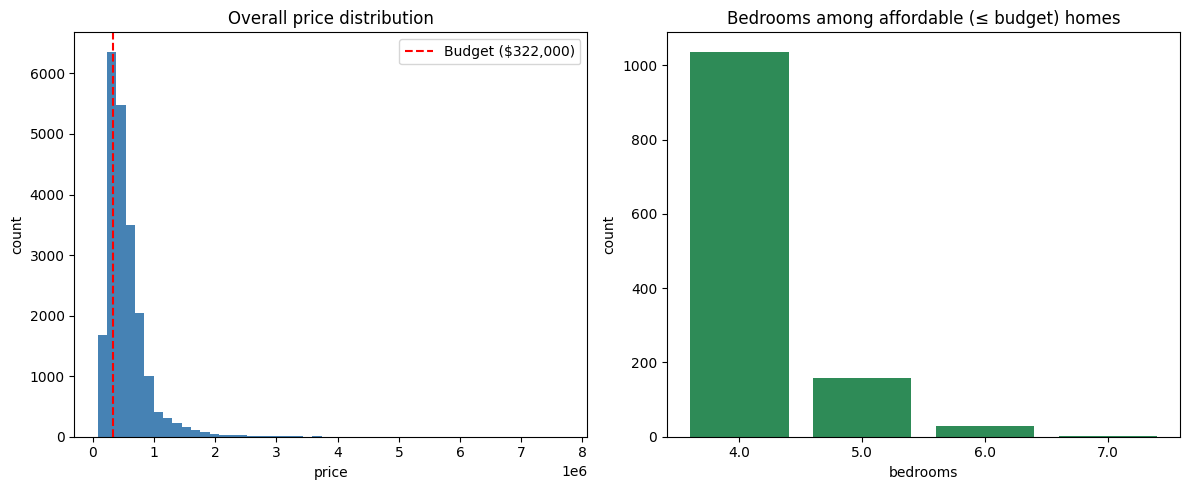

In [7]:
# Define Thomas Hansen's budget: bottom 25% of all sale prices
budget = df["price"].quantile(0.25)
print(f"Budget ceiling (25th percentile of price): ${budget:,.0f}")

# Candidate homes: 4+ bedrooms, within budget
candidates = df[(df["bedrooms"] >= 4) & (df["price"] <= budget)].copy()
print(f"Homes with 4+ bedrooms within budget: {len(candidates)}")
print(f"Share of all sales that this represents: {len(candidates) / len(df):.1%}")

# Visualize: price distribution, budget line, and how many bedrooms are affordable
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["price"], bins=50, color="steelblue")
axes[0].axvline(budget, color="red", linestyle="--", label=f"Budget (${budget:,.0f})")
axes[0].set_title("Overall price distribution")
axes[0].set_xlabel("price")
axes[0].set_ylabel("count")
axes[0].legend()

bedroom_counts = candidates["bedrooms"].value_counts().sort_index()
axes[1].bar(bedroom_counts.index.astype(str), bedroom_counts.values, color="seagreen")
axes[1].set_title("Bedrooms among affordable (≤ budget) homes")
axes[1].set_xlabel("bedrooms")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

### Hypothesis 2 — Finding a "nice" and "social" neighborhood within budget

Among the affordable, family-sized `candidates` from Hypothesis 1, we group by `zipcode` and look for areas with both a high count of qualifying homes (social density) and above-average condition/grade (niceness).

         num_affordable_family_homes  avg_price  avg_condition  avg_grade  \
zipcode                                                                     
98092                             63 280982.700          3.300      7.700   
98023                            130 267544.300          3.400      7.500   
98032                             40 270102.900          3.800      7.400   
98003                             45 263456.700          3.400      7.400   
98031                             76 281398.300          3.600      7.300   
98042                             81 274242.400          3.400      7.200   
98038                             45 288264.400          3.200      7.200   
98001                             88 256722.000          3.300      7.100   
98030                             56 269004.400          3.300      7.100   
98148                              7 252027.100          3.000      7.100   

         avg_sqft_living  
zipcode                   
98092           2040.

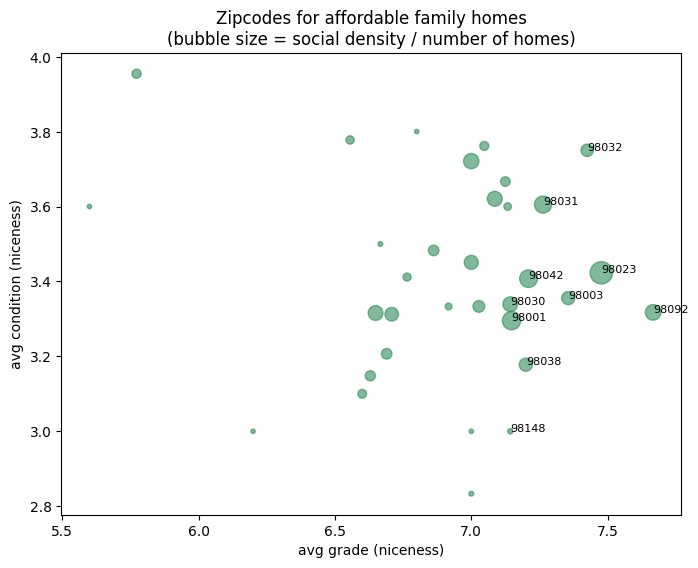

In [8]:
# Aggregate candidates by zipcode
zipcode_stats = (
    candidates.groupby("zipcode")
    .agg(
        num_affordable_family_homes=("price", "count"),
        avg_price=("price", "mean"),
        avg_condition=("condition", "mean"),
        avg_grade=("grade", "mean"),
        avg_sqft_living=("sqft_living", "mean"),
    )
    .query("num_affordable_family_homes >= 5")
    .sort_values(["avg_grade", "avg_condition", "num_affordable_family_homes"], ascending=False)
)

top_zipcodes = zipcode_stats.head(10)
print(top_zipcodes.round(1))

# Visualize: social density (count) vs. niceness (grade) per zipcode, sized by count
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    zipcode_stats["avg_grade"],
    zipcode_stats["avg_condition"],
    s=zipcode_stats["num_affordable_family_homes"] * 2,
    alpha=0.6,
    color="seagreen",
)
for zc in top_zipcodes.index:
    ax.annotate(
        str(zc),
        (zipcode_stats.loc[zc, "avg_grade"], zipcode_stats.loc[zc, "avg_condition"]),
        fontsize=8,
    )
ax.set_xlabel("avg grade (niceness)")
ax.set_ylabel("avg condition (niceness)")
ax.set_title("Zipcodes for affordable family homes\n(bubble size = social density / number of homes)")
plt.show()

### Geographical view — where do the affordable, family-sized homes actually sit?

Plotting `lat`/`long` for the `candidates` (colored by zipcode) shows the geographic clustering behind the Hypothesis 2 numbers, rather than just a table of zipcodes.

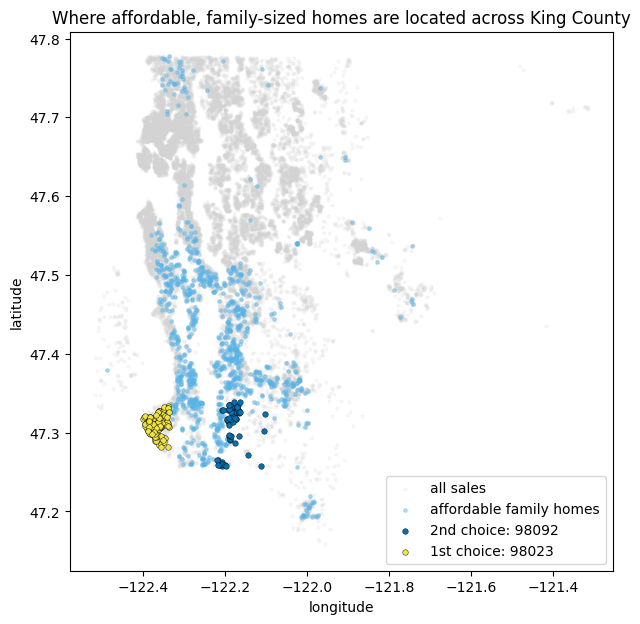

In [9]:

# Priority order per Insight 2: 98023 has by far the strongest social density
# (130 vs. 63 qualifying homes), a lower avg price ($267.5K vs. $281.0K), and a
# better avg condition (3.4 vs. 3.3) than 98092 — despite a marginally lower avg
# grade (7.5 vs. 7.7) — so it's the 1st choice; 98092 is the 2nd choice / backup.
first_choice_zipcode = 98023
second_choice_zipcode = 98092

# Colorblind-safe palette (Okabe-Ito): blue for the 2nd choice, yellow for the 1st choice,
# so the top recommendation reads as the most visually prominent.
color_all_sales = "lightgray"
color_candidates = "#56B4E9"  # sky blue
color_second_choice = "#0072B2"  # blue
color_first_choice = "#F0E442"  # yellow

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(df["long"], df["lat"], s=4, alpha=0.15, color=color_all_sales, label="all sales")
ax.scatter(
    candidates["long"], candidates["lat"], s=6, alpha=0.4, color=color_candidates,
    label="affordable family homes",
)
ax.scatter(
    candidates.loc[candidates["zipcode"] == second_choice_zipcode, "long"],
    candidates.loc[candidates["zipcode"] == second_choice_zipcode, "lat"],
    s=16, color=color_second_choice, edgecolor="black", linewidth=0.3,
    label=f"2nd choice: {second_choice_zipcode}",
)
ax.scatter(
    candidates.loc[candidates["zipcode"] == first_choice_zipcode, "long"],
    candidates.loc[candidates["zipcode"] == first_choice_zipcode, "lat"],
    s=16, color=color_first_choice, edgecolor="black", linewidth=0.3,
    label=f"1st choice: {first_choice_zipcode}",
)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("Where affordable, family-sized homes are located across King County")
ax.legend()
plt.show()

### Hypothesis 3 — Best timing to buy

Group the same `candidates` segment by sale month to see whether price varies meaningfully across the year.

       num_sales  avg_price
month                      
1             67 266900.000
2             84 266883.000
3            100 266999.000
4             98 277878.000
5            124 266942.000
6            124 267795.000
7            121 262992.000
8            102 270929.000
9            110 267252.000
10           120 265425.000
11            79 282673.000
12            98 261149.000

Cheapest month: 12 ($261,149)
Priciest month: 11 ($282,673)
Swing across the year: 8.0%


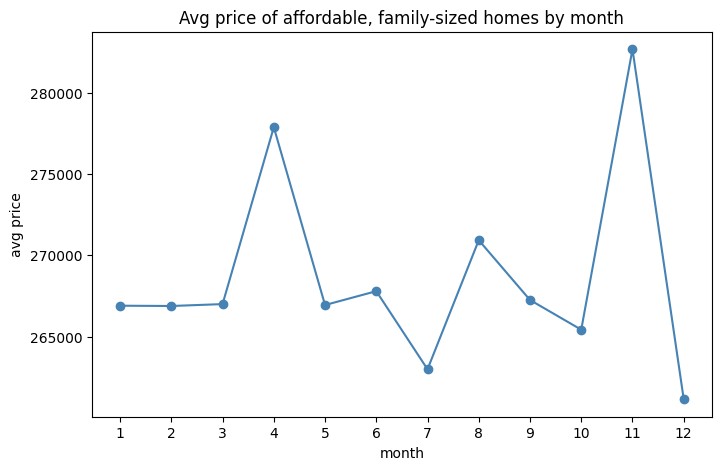

In [10]:
monthly = (
    candidates.assign(month=candidates["date"].dt.month)
    .groupby("month")
    .agg(num_sales=("price", "count"), avg_price=("price", "mean"))
)
print(monthly.round(0))

cheapest_month = monthly["avg_price"].idxmin()
priciest_month = monthly["avg_price"].idxmax()
swing = (monthly["avg_price"].max() - monthly["avg_price"].min()) / monthly["avg_price"].mean()
print(f"\nCheapest month: {cheapest_month} (${monthly.loc[cheapest_month, 'avg_price']:,.0f})")
print(f"Priciest month: {priciest_month} (${monthly.loc[priciest_month, 'avg_price']:,.0f})")
print(f"Swing across the year: {swing:.1%}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(monthly.index, monthly["avg_price"], marker="o", color="steelblue")
ax.set_xticks(range(1, 13))
ax.set_xlabel("month")
ax.set_ylabel("avg price")
ax.set_title("Avg price of affordable, family-sized homes by month")
plt.show()

## Insights and recommendations for Thomas Hansen

**Insight 1 (feasibility):** Even at a strict "no money" budget (≤ 25th percentile of price), there are over a thousand 4+ bedroom homes available — a family of 7 is realistically housed within this budget in King County.

**Insight 2 (location, the geographical insight):** Two zipcodes stand out among affordable, family-sized homes, both at a price well under budget with above-average condition and grade:
- **98023 (1st choice)** has by far the strongest "social" density — 130 qualifying homes, roughly double any other zipcode — a lower avg price (\$267.5K vs. \$281.0K), and a better avg condition (3.4 vs. 3.3) than 98092, despite a marginally lower avg grade (7.5 vs. 7.7).
- **98092 (2nd choice)** has the single highest avg grade (7.7) among qualifying zipcodes, but only 63 qualifying homes, a higher avg price, and a slightly lower avg condition — a solid backup, just less "socially dense" and less affordable.

The affordable-family-home map highlights both (98023 in yellow, 98092 in blue) and shows these homes cluster geographically rather than being spread evenly across the county.

**Insight 3 (timing):** Prices for this segment are fairly flat across the year (~8% swing). Timing matters far less than location for this client — but if he can be flexible, buying toward **December** offers a modest discount versus **November**, the priciest month.

**Recommendations for Thomas:**
1. Focus his search on **zipcode 98023 first**, then **98092 as a backup** — 98023 offers the best combination of affordability (lower avg price), family-home availability, community density, and condition; 98092 is a close second with a slightly higher average grade but far fewer qualifying homes, a higher price, and a slightly lower condition.
2. Don't over-optimize for timing — the ~8% seasonal swing is small compared to the difference between zipcodes; location should drive the decision, not the calendar.
3. If flexible on timing, aim to close toward the **end of the year** for a modest additional discount.